<a href="https://colab.research.google.com/github/GustavoHDLC1/Colab_Files_PADP/blob/main/Clasificaci%C3%B3n_de_Texto_NSup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import string
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata
import nltk
from nltk import word_tokenize
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import PCA
import warnings
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 100)


In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
def clean_text(text):
    text = re.sub(r'[^\w\s]', '', text)  # quita puntuación
    return text

In [4]:
def plot_wordcloud(text, title):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100
    ).generate(text)

    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

In [5]:
dataset = fetch_20newsgroups(subset='all', remove=('headers','footers','quotes'))
docs_raw = dataset.data

In [6]:
# lista de stopwords de nltk
stopwords = list(set(stopwords.words('english')))

In [7]:
vectorizer = TfidfVectorizer(lowercase=True, stop_words=stopwords, preprocessor=clean_text, max_features=100, ngram_range=(1,2), min_df=3, max_df=0.9)
X = vectorizer.fit_transform(docs_raw)

In [8]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 182616 stored elements and shape (18846, 100)>

In [9]:
# Rango de k a probar
k_values = range(2, 10)

In [10]:
inertia = []
silhouette = []

In [11]:
for k in k_values:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = kmeans.fit_predict(X)

  inertia.append(kmeans.inertia_)
  silhouette.append(silhouette_score(X, labels))


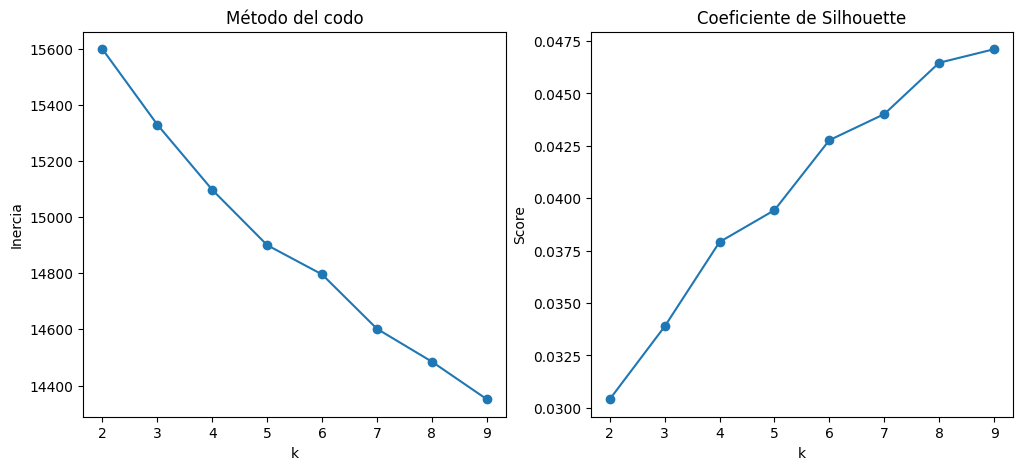

In [12]:
# ===== Gráficas =====
plt.figure(figsize=(12,5))

# Método del codo
plt.subplot(1,2,1)
plt.plot(k_values, inertia, marker='o')
plt.title('Método del codo')
plt.xlabel('k')
plt.ylabel('Inercia')

# Silhouette
plt.subplot(1,2,2)
plt.plot(k_values, silhouette, marker='o')
plt.title('Coeficiente de Silhouette')
plt.xlabel('k')
plt.ylabel('Score')

plt.show()

Al considerar el método del codo no se observa de manera clara un punto en el que la gráfica deje de decrecer significativamente, solo se observa que de 5 a 6 el decremento es menor, pero no suficiente para decir que es el punto que buscamos, por otro lado, usando el coeficiente de Silhouette sucede algo similar, donde no hay un punto claro donde el valor deje de crecer considerablemente, solo vemos que de 4 a 5 es el incremento mas pequeño, pero no es el ideal, además al ver que los valores están por debajo de 0.5 junto con las otras características ya mencionadas, podemos deducir que no existen segmentaciones claras en los datos, es por ello que no encontramos un valor adecuado para el número de clusteres, así que considerando todo lo anterior, se decide tomar k = 5

In [13]:
# Aplicar K-Means con K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

In [14]:
X_dense = X.toarray()

In [15]:
sil = silhouette_score(X, labels)
db = davies_bouldin_score(X_dense, labels)
ch = calinski_harabasz_score(X_dense, labels)

print(f"Silhouette: {sil:.4f}")
print(f"Davies-Bouldin: {db:.4f}")
print(f"Calinski-Harabasz: {ch:.4f}")

Silhouette: 0.0394
Davies-Bouldin: 5.1557
Calinski-Harabasz: 338.9236


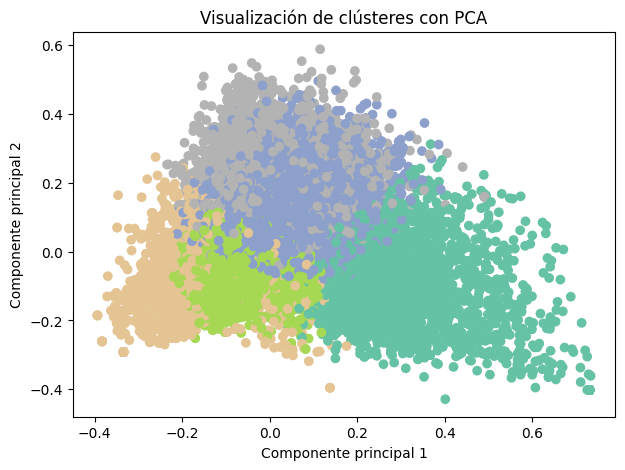

In [16]:
# Reducción a 2 dimensiones
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='Set2')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Visualización de clústeres con PCA')
plt.show()

De lo anterior, recordando que Silhouette toma valores de -1 a 1 y entre mas cercanos a 1 indica un mejor desempeño, con el valor que tenemos actualmente muy cercano a 0 nos indica que existe superposición, es decir, los puntos están igual de cerca del cluster que se asigno que de otros, para el valor de Davies Bouldin esperamos valores cercanos a 0, en este caso es mayor a 5, y esto indica que los clusters no son compactos, es decir, se encuentran muy dispersos.

In [17]:
l_sil = []
l_db = []
l_ch = []
l_model = []
l_sil.append(sil)
l_db.append(db)
l_ch.append(ch)
l_model.append('Kmeans=5')

In [18]:
results = []

eps_values = np.linspace(0.3, 1.5, 10)
min_samples_values = [5, 10, 15]

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)

        # Ignorar si solo hay un cluster o todo es ruido
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.sum(labels == -1) / len(labels)

        if n_clusters > 1:
            sil = silhouette_score(X, labels)
        else:
            sil = -1

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": sil
        })

In [19]:
df_results = pd.DataFrame(results)
df_results.sort_values(by="silhouette", ascending=False).head(10)

,eps,min_samples,n_clusters,noise_ratio,silhouette
7,0.566667,10,73,0.820811,-0.110639
6,0.566667,5,110,0.797729,-0.119264
8,0.566667,15,46,0.843044,-0.121043
11,0.700000,15,37,0.705879,-0.132639
3,0.433333,5,107,0.846705,-0.133712
4,0.433333,10,56,0.865913,-0.136039
5,0.433333,15,28,0.883477,-0.137383
1,0.300000,10,43,0.879550,-0.137957
0,0.300000,5,103,0.858538,-0.140384
10,0.700000,10,32,0.672822,-0.141037


Similar al caso anterior con Kmeans, los modelos propuestos tienen métricas de desempeño muy malas, ya que el silhouette negativo indica superposición, además de que la mayor parte de los puntos se identifican como ruido

In [20]:
db = DBSCAN(eps=0.566667, min_samples=10)
labels_db = db.fit_predict(X)

In [21]:
sil = silhouette_score(X, labels_db)
db1 = davies_bouldin_score(X_dense, labels_db)
ch = calinski_harabasz_score(X_dense, labels_db)

print(f"Silhouette: {sil:.4f}")
print(f"Davies-Bouldin: {db1:.4f}")
print(f"Calinski-Harabasz: {ch:.4f}")

Silhouette: -0.1106
Davies-Bouldin: 1.3811
Calinski-Harabasz: 31.2647


In [22]:
l_sil.append(sil)
l_db.append(db1)
l_ch.append(ch)
l_model.append('DBSCAN')

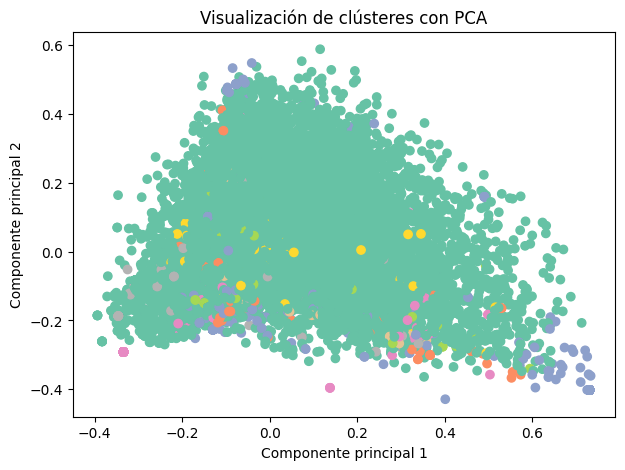

In [23]:
# Reducción a 2 dimensiones
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db.labels_, cmap='Set2')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Visualización de clústeres con PCA')
plt.show()

In [24]:
df = pd.DataFrame({
    'Modelo': l_model,
    'Silhouette': l_sil,
    'Davies_Bouldin': l_db,
    'Calinski_Harabasz': l_ch
})

In [26]:
docs = docs_raw

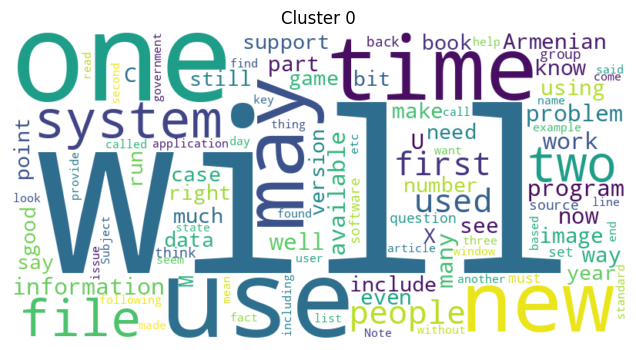

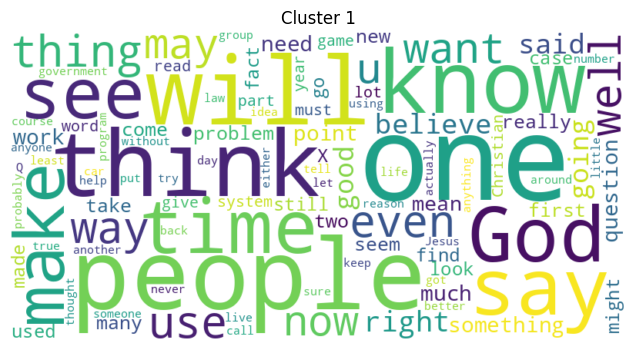

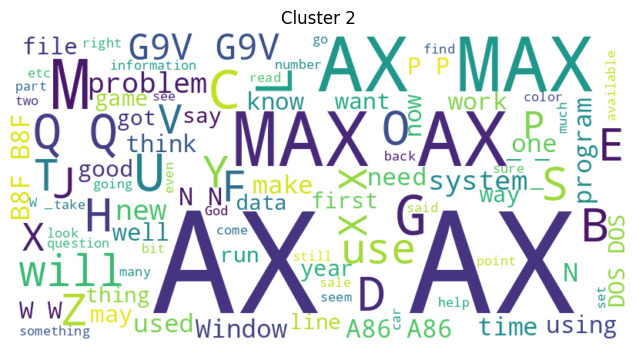

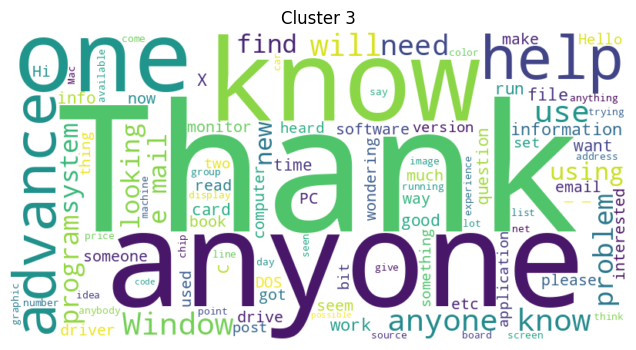

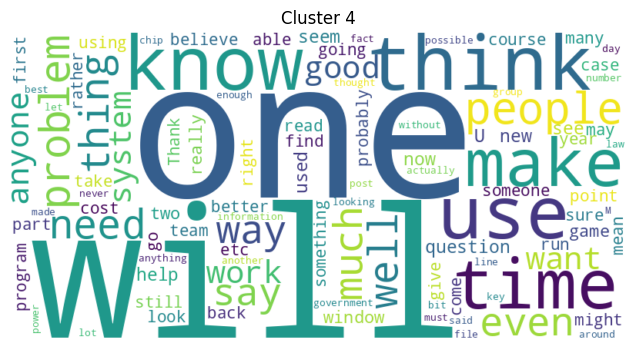

In [31]:
clusters = np.unique(labels)

for c in clusters:
    texts = [docs[i] for i in range(len(docs)) if labels[i] == c]
    combined_text = " ".join(texts)

    plot_wordcloud(combined_text, f"Cluster {c}")

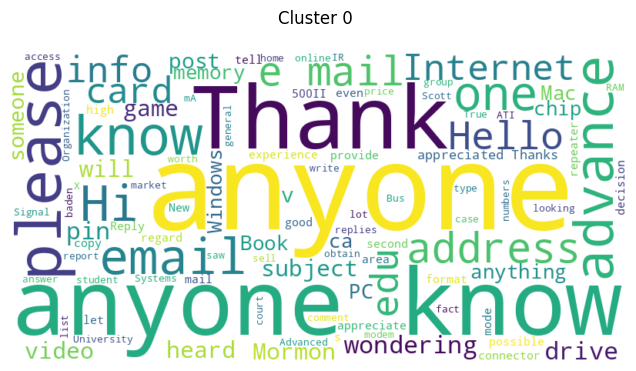

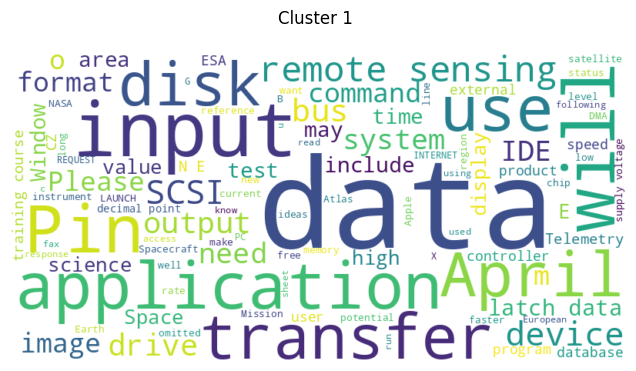

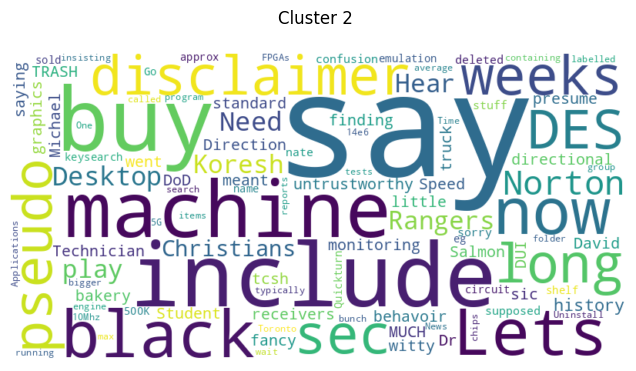

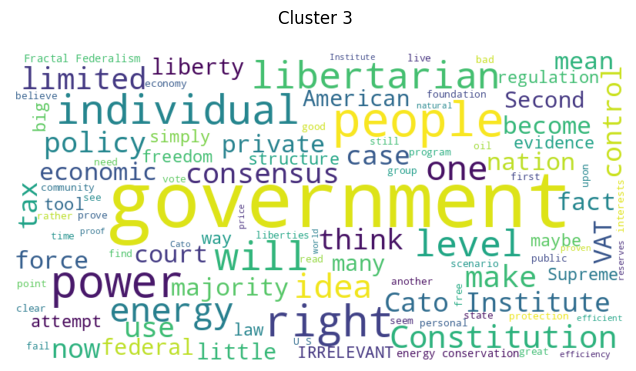

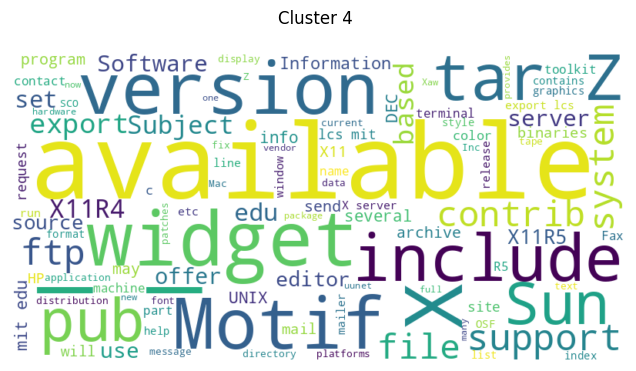

In [28]:
clusters = [c for c in np.unique(labels_db) if c != -1]

# Tomar solo los primeros 5
clusters = clusters[:5]

for c in clusters:
    texts = [docs[i] for i in range(len(docs)) if labels_db[i] == c]
    combined_text = " ".join(texts)

    plot_wordcloud(combined_text, f"Cluster {c} \n")

Como podemos observar, ninguno de los modelos tiene buen desempeño, esto era de esperar ya que limitamos los vectores a un tamaño de 100, lo cual es muy poco para entrenar esta clase de modelos, pero sirve perfecto como ejemplo ilustrativo, ya que procesar los datos necesarios para modelos mas robustos requieren de una gran capacidad de cómputo, es decir, consumen demasiados recursos.

In [32]:
df

,Modelo,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,Kmeans=5,0.039430,5.155740,338.923581
1,DBSCAN,-0.110639,1.381112,31.264680
